# Prediction of Red Blood Cells Parasitized by Malaria

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [ ]:
!unzip malaria_rbc.zip

# Parameters

In [3]:
# How many images we can reliably fit into computer memory
batch_size = 1000

# Number of training epochs
n_epochs = 10

# Load data

In [4]:
# Read in image data
data = datasets.ImageFolder(
    root="malaria_rbc",
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
        ]
    ),
)

# Extract slide names from file paths
slides = []
for img in data.imgs:
    fname = Path(img[0]).name
    slides.append(fname.split("_cell")[0])

# Split data into train and test sets, ensuring slides are kept together
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1)
train_indices, test_indices = next(splitter.split(range(len(data)), groups=slides))
train_data = Subset(data, train_indices)
test_data = Subset(data, test_indices)

# Compute mean and stdev of train_data images
# Note: this could be sped up by using batches
u = torch.zeros(3)
u2 = torch.zeros(3)
n = 0
for image, _ in train_data:
    u += image.mean([1, 2])  # images are stored (3, 28, 28)
    u2 += (image**2).mean([1, 2])
    n += 1
u /= n
u2 /= n
s = (u2 - u**2).sqrt()

# Add normalization to dataset transform
normalization = transforms.Normalize(u.tolist(), s.tolist())
data.transform.transforms.append(normalization)

# Create DataLoaders

In [5]:
# Create data loaders
train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
)

# Visualize data

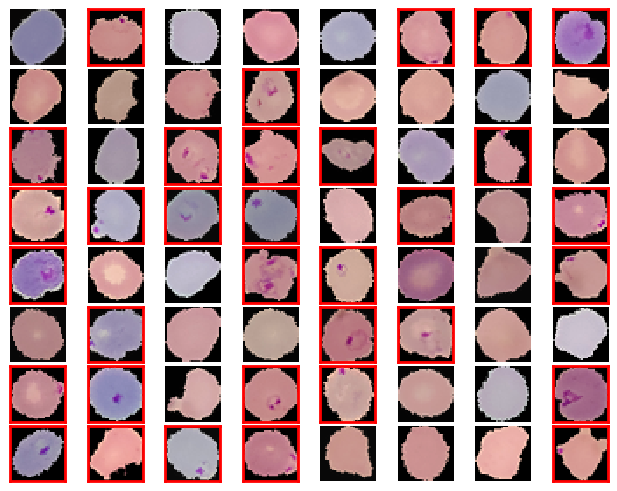

In [6]:
images, labels = next(iter(train_loader))
n = np.min([images.shape[0], 64])
ncol = int(np.sqrt(n))
nrow = n // ncol
fig, ax = plt.subplots(ncol, nrow)
k = -1
for row in range(nrow):
    for col in range(ncol):
        k = k + 1
        image = images[k, :, :, :] * s[:, None, None] + u[:, None, None]
        ax[row, col].imshow(
            np.transpose(np.clip(image, 0, 1), [1, 2, 0]),
            interpolation="nearest",
        )
        if labels[k] == 1:
            ax[row, col].axis("on")
            ax[row, col].set_xticks([])
            ax[row, col].set_yticks([])
            for spine in ax[row, col].spines.values():
                spine.set_linewidth(2)
                spine.set_edgecolor("red")
        else:
            ax[row, col].axis("off")
plt.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout(pad=0.3)

# LeNet

In [7]:
model = nn.Sequential(
    nn.Conv2d(3, 6, 5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, 5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16*6*6, 176),
    torch.nn.ReLU(),
    nn.Linear(176, 86),
    torch.nn.ReLU(),
    nn.Linear(86, 10),
    nn.ReLU(),
    torch.nn.Linear(10, 1),
    torch.nn.Sigmoid(),
)

In [8]:
model

Sequential(
  (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=576, out_features=176, bias=True)
  (8): ReLU()
  (9): Linear(in_features=176, out_features=86, bias=True)
  (10): ReLU()
  (11): Linear(in_features=86, out_features=10, bias=True)
  (12): ReLU()
  (13): Linear(in_features=10, out_features=1, bias=True)
  (14): Sigmoid()
)

## Train

In [9]:
# Put model into training mode
model.train()

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

# Training loop
losses = []
for epoch in range(n_epochs):
    for X, y in train_loader:
        optimizer.zero_grad()
        yhat = model(X)
        loss = loss_fn(yhat, y.float().view(-1, 1))
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
    print(losses[-1])

0.6372491717338562
0.6023752093315125
0.5471879839897156
0.4676797091960907
0.4548969566822052
0.4561408758163452
0.37425240874290466
0.3317842483520508
0.29543763399124146
0.3125033974647522


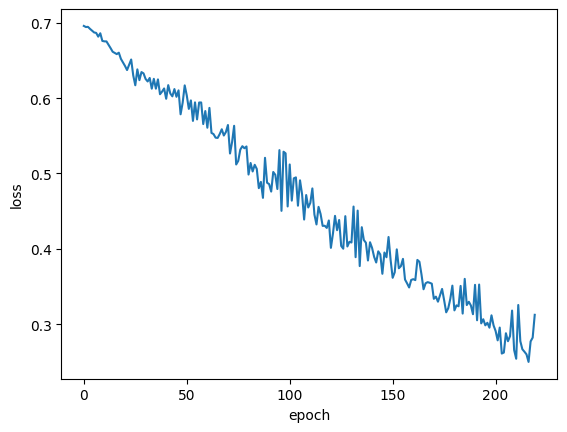

In [10]:
fig, ax = plt.subplots()
ax.plot(losses)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
plt.show()

## Evaluate

In [11]:
# Evaluate model
model.eval()

# Training
ys = []
yhats = []
for X, y in train_loader:
    ys.extend(y.numpy().tolist())
    yhats.extend(model(X).detach().numpy().tolist())
print("train")
print("accuracy =", accuracy_score(ys, np.array(yhats) > 0.5))
print("precision =", precision_score(ys, np.array(yhats) > 0.5))
print("recall =", recall_score(ys, np.array(yhats) > 0.5))
print("roc auc =", roc_auc_score(ys, yhats))

# Testing
ys = []
yhats = []
for X, y in test_loader:
    ys.extend(y.numpy().tolist())
    yhats.extend(model(X).detach().numpy().tolist())
print("\ntest")
print("accuracy =", accuracy_score(ys, np.array(yhats) > 0.5))
print("precision =", precision_score(ys, np.array(yhats) > 0.5))
print("recall =", recall_score(ys, np.array(yhats) > 0.5))
print("roc auc =", roc_auc_score(ys, yhats))

train
accuracy = 0.8913023637857078
precision = 0.9107020464114364
recall = 0.863522421316498
roc auc = 0.9586675953133067

test
accuracy = 0.8890857547838412
precision = 0.9152719665271967
recall = 0.8726728723404256
roc auc = 0.9574452950957286
